In [49]:
import numpy as np
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
news_df = pd.read_csv('/Users/riteshkumar/Downloads/ML/fake news detection model/train.csv')  # Add the correct filename


In [51]:
news_df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


# About the Dataset:

id: unique id for a news article                                     
title: the title of a news article                                  
author: author of the news article                                    
text: the text of the article; could be incomplete                                        
label: a label that marks whether the news article is real or fake:                              
    1: Fake news                                                 
    0: real News                                        

# 1 Preprocessing 

In [52]:
news_df.isnull().sum()

id           0
title      558
author    1957
text        39
label        0
dtype: int64

In [53]:
news_df.shape

(20800, 5)

In [54]:
news_df = news_df.fillna(' ')

In [55]:
news_df.isnull().sum()

id        0
title     0
author    0
text      0
label     0
dtype: int64

In [56]:
news_df['content'] = news_df['author']+' '+news_df['title']

In [57]:
news_df

,id,title,author,text,label,content
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1,Darrell Lucus House Dem Aide: We Didn’t Even S...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1,Consortiumnews.com Why the Truth Might Get You...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1,Jessica Purkiss 15 Civilians Killed In Single ...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1,Howard Portnoy Iranian woman jailed for fictio...
...,...,...,...,...,...,...
20795,20795,Rapper T.I.: Trump a ’Poster Child For White S...,Jerome Hudson,Rapper T. I. unloaded on black celebrities who...,0,Jerome Hudson Rapper T.I.: Trump a ’Poster Chi...
20796,20796,"N.F.L. Playoffs: Schedule, Matchups and Odds -...",Benjamin Hoffman,When the Green Bay Packers lost to the Washing...,0,"Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma..."
20797,20797,Macy’s Is Said to Receive Takeover Approach by...,Michael J. de la Merced and Rachel Abrams,The Macy’s of today grew from the union of sev...,0,Michael J. de la Merced and Rachel Abrams Macy...
20798,20798,"NATO, Russia To Hold Parallel Exercises In Bal...",Alex Ansary,"NATO, Russia To Hold Parallel Exercises In Bal...",1,"Alex Ansary NATO, Russia To Hold Parallel Exer..."


# separating the data & label

In [58]:
X = news_df.drop('label',axis=1)
y = news_df['label']

In [59]:
print(X)

          id                                              title  \
0          0  House Dem Aide: We Didn’t Even See Comey’s Let...   
1          1  FLYNN: Hillary Clinton, Big Woman on Campus - ...   
2          2                  Why the Truth Might Get You Fired   
3          3  15 Civilians Killed In Single US Airstrike Hav...   
4          4  Iranian woman jailed for fictional unpublished...   
...      ...                                                ...   
20795  20795  Rapper T.I.: Trump a ’Poster Child For White S...   
20796  20796  N.F.L. Playoffs: Schedule, Matchups and Odds -...   
20797  20797  Macy’s Is Said to Receive Takeover Approach by...   
20798  20798  NATO, Russia To Hold Parallel Exercises In Bal...   
20799  20799                          What Keeps the F-35 Alive   

                                          author  \
0                                  Darrell Lucus   
1                                Daniel J. Flynn   
2                             Consortiu

# Stemming:

Stemming is the process of reducing a word to its Root word

example: hung         hanged        hanging ======hang

# Steps:
lower case                 
splitting                             
removing stopwords                              
stemming                                   

In [60]:
ps = PorterStemmer()
def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]',' ',content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [ps.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

In [61]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/riteshkumar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [62]:
news_df['content']

0        Darrell Lucus House Dem Aide: We Didn’t Even S...
1        Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo...
2        Consortiumnews.com Why the Truth Might Get You...
3        Jessica Purkiss 15 Civilians Killed In Single ...
4        Howard Portnoy Iranian woman jailed for fictio...
                               ...                        
20795    Jerome Hudson Rapper T.I.: Trump a ’Poster Chi...
20796    Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma...
20797    Michael J. de la Merced and Rachel Abrams Macy...
20798    Alex Ansary NATO, Russia To Hold Parallel Exer...
20799              David Swanson What Keeps the F-35 Alive
Name: content, Length: 20800, dtype: object

# separating the data and label


In [63]:
X = news_df['content'].values
y = news_df['label'].values

# converting the textual data to numerical data

In [64]:
vector = TfidfVectorizer()
vector.fit(X)
X = vector.transform(X)

In [65]:
print(X)

  (0, 904)	0.26354004814013343
  (0, 3862)	0.30579573877221844
  (0, 4507)	0.20531415441295317
  (0, 5508)	0.2993429551929777
  (0, 5800)	0.2502787762405247
  (0, 6145)	0.24677171892553343
  (0, 7574)	0.23047267305353566
  (0, 10387)	0.1844880289323935
  (0, 11307)	0.1532265401605094
  (0, 11409)	0.20615188166061463
  (0, 12528)	0.24883399099107747
  (0, 12902)	0.3024224900242886
  (0, 19171)	0.22537992364975484
  (0, 22289)	0.3484071341454308
  (0, 22649)	0.26575278886038384
  (0, 23355)	0.18006497451107856
  (1, 2544)	0.2899843833664323
  (1, 3075)	0.15310531118537438
  (1, 3509)	0.37751839443307017
  (1, 4298)	0.19024289659874757
  (1, 5469)	0.2624012615566619
  (1, 8420)	0.7045992054867243
  (1, 10134)	0.18787145765749733
  (1, 15149)	0.15862263711495958
  (1, 23748)	0.2966210296019264
  :	:
  (20797, 17253)	0.2367895682882451
  (20797, 17550)	0.30237144153210893
  (20797, 18720)	0.2367895682882451
  (20797, 21266)	0.29969673985755974
  (20797, 21564)	0.06321126907384642
  (20797, 

# Splitting the dataset to training & test data

In [66]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=2)

In [67]:
X_train.shape

(16640, 25173)

# Training the Model: TensorFlow

In [68]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),  # TensorFlow dense layer
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # For binary classification (Fake/Real) (0,1)
])


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [70]:
model.fit(X_train, Y_train, epochs=5, batch_size=64, validation_split=0.1)


Epoch 1/5
 70/234 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6681 - loss: 0.6465

KeyboardInterrupt: 

# Detection System

In [ ]:
# Evaluate the model
train_loss, train_acc = model.evaluate(X_train, Y_train)
test_loss, test_acc = model.evaluate(X_test, Y_test)

# Predict on test set
predictions = model.predict(X_test)

# Convert to binary (0 or 1)
binary_predictions = (predictions > 0.5).astype(int).flatten()

# Compare predictions with actual labels
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(Y_test, binary_predictions))
print("Classification Report:\n", classification_report(Y_test, binary_predictions))

520/520 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 2.4814e-04
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9851 - loss: 0.0476
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.989423076923077
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2077
           1       0.99      0.99      0.99      2083

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



In [ ]:
# Compute the confusion matrix
cm = confusion_matrix(Y_test, binary_predictions)

# Define class labels
labels = ['Real News (0)', 'Fake News (1)']


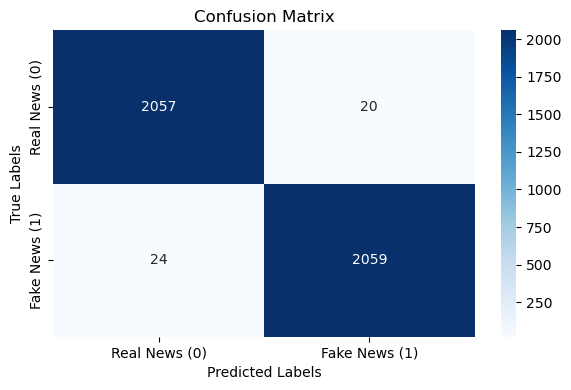

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# For scikit-learn models only
import pickle

model.save('fake_news_model.h5')
print("Model saved as 'fake_news_model.h5'")

# Save the vectorizer
with open('fake news.pkl', 'wb') as f:
    pickle.dump(vector, f)

print("TF-IDF vectorizer saved as 'fake news.pkl'")



Model saved as 'fake_news_model.h5'
TF-IDF vectorizer saved as 'fake news.pkl'


# python file.py

In [ ]:
import streamlit as st
import pickle
import numpy as np
import tensorflow as tf

# Load the saved TF-IDF vectorizer
with open('fake news.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Load the trained Keras model
model = tf.keras.models.load_model('fake_news_model.h5')

# Streamlit UI
st.title("Fake News Detection")

# Input text box
user_input = st.text_area("Enter the news content to check:")

if st.button("Predict"):
    if user_input.strip() == "":
        st.warning("Please enter some text to predict.")
    else:
        # Vectorize user input
        vect_input = vectorizer.transform([user_input])
        
        # Convert sparse matrix to dense for Keras model
        vect_input_dense = vect_input.toarray()
        
        # Predict
        prediction_prob = model.predict(vect_input_dense)[0][0]
        prediction = "Fake News" if prediction_prob > 0.5 else "Real News"
        
        st.write(f"Prediction: **{prediction}**")
        st.write(f"Confidence score: {prediction_prob:.4f}")
